In [6]:
import pandas as pd
from nba_api.stats.endpoints import leaguegamelog

# Pull last 2 complete NBA seasons
seasons = ['2024-25', '2025-26']
all_games = []

for season in seasons:
    print(f"Fetching season {season}...")
    log = leaguegamelog.LeagueGameLog(season=season, season_type_all_star='Regular Season')
    df = log.get_data_frames()[0]
    all_games.append(df)

raw_df = pd.concat(all_games, ignore_index=True)
print(f"Total raw rows loaded: {len(raw_df)}")
display(raw_df.head(2))

Fetching season 2024-25...
Fetching season 2025-26...
Total raw rows loaded: 4920


,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,FGM,...,DREB,REB,AST,STL,BLK,TOV,PF,PTS,PLUS_MINUS,VIDEO_AVAILABLE
0,22024,1610612738,BOS,Boston Celtics,0022400061,2024-10-22,BOS vs. NYK,W,240,48,...,29,40,33,6,3,4,15,132,23,1
1,22024,1610612747,LAL,Los Angeles Lakers,0022400062,2024-10-22,LAL vs. MIN,W,240,42,...,31,46,22,7,8,7,22,110,7,1


In [7]:
import numpy as np

# 1. Clean and sort chronologically
df = raw_df.copy()
df['GAME_DATE'] = pd.to_datetime(df['GAME_DATE'])
df = df.sort_values(['GAME_DATE', 'GAME_ID']).reset_index(drop=True)

# Parse Home/Away: '@' means away, 'vs.' means home
df['IS_HOME'] = df['MATCHUP'].apply(lambda x: 0 if '@' in x else 1)

# Split into Home and Away dataframes and merge back to create a single row per game
home_df = df[df['IS_HOME'] == 1].copy()
away_df = df[df['IS_HOME'] == 0].copy()

# Rename columns for merging
home_df = home_df.add_suffix('_home')
away_df = away_df.add_suffix('_away')

# Merge on GAME_ID
games = pd.merge(
    home_df, away_df,
    left_on=['GAME_ID_home', 'SEASON_ID_home'],
    right_on=['GAME_ID_away', 'SEASON_ID_away']
)

games['GAME_DATE'] = games['GAME_DATE_home']
games = games.sort_values('GAME_DATE').reset_index(drop=True)

print(f"Processed into {len(games)} unique match rows.")

Processed into 2450 unique match rows.


In [8]:
# 2. Sequential Elo & Rolling Metrics Engine
elos = {}
base_elo = 1500.0
k_factor = 20.0

def get_elo(team_id, season):
    key = (team_id, season)
    if key not in elos:
        elos[key] = base_elo
    return elos[key]

home_elos, away_elos = [], []
current_season = None

for idx, row in games.iterrows():
    season = row['SEASON_ID_home']
    if season != current_season:
        current_season = season
        # Reset elos at season boundary
        elos.clear()
        
    h_id = row['TEAM_ID_home']
    a_id = row['TEAM_ID_away']
    
    h_elo = get_elo(h_id, season)
    a_elo = get_elo(a_id, season)
    
    home_elos.append(h_elo)
    away_elos.append(a_elo)
    
    # Expected scores
    exp_h = 1 / (1 + 10 ** ((a_elo - h_elo) / 400))
    exp_a = 1 / (1 + 10 ** ((h_elo - a_elo) / 400))
    
    # Actual outcome (1 for win, 0 for loss)
    act_h = 1.0 if row['WL_home'] == 'W' else 0.0
    act_a = 1.0 - act_h
    
    # Update Elos for next game
    elos[(h_id, season)] = h_elo + k_factor * (act_h - exp_h)
    elos[(a_id, season)] = a_elo + k_factor * (act_a - exp_a)

games['HOME_ELO'] = home_elos
games['AWAY_ELO'] = away_elos
games['ELO_DIFF'] = games['HOME_ELO'] - games['AWAY_ELO']
games['TARGET'] = (games['WL_home'] == 'W').astype(int)

print("Elo calculation complete. Ready for modeling prep.")

Elo calculation complete. Ready for modeling prep.


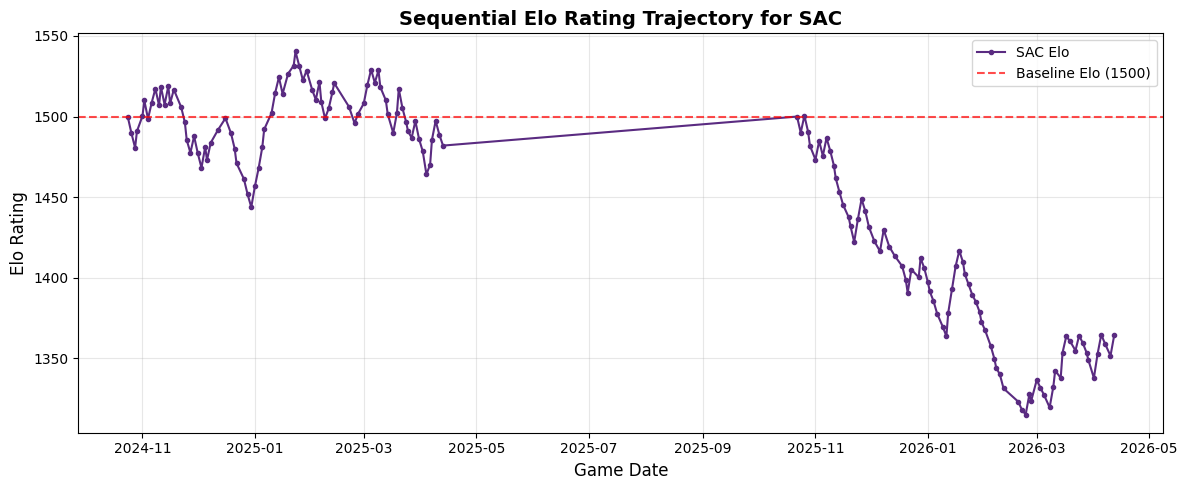

In [33]:
import matplotlib.pyplot as plt

# Pick team abbreviation for the Sacramento Kings
team_abbr = 'SAC'
team_games = games[
    (games['TEAM_ABBREVIATION_home'] == team_abbr) | 
    (games['TEAM_ABBREVIATION_away'] == team_abbr)
].copy()

# Extract their chronological Elo rating
dates, elos = [], []
for _, r in team_games.iterrows():
    if r['TEAM_ABBREVIATION_home'] == team_abbr:
        dates.append(r['GAME_DATE'])
        elos.append(r['HOME_ELO'])
    else:
        dates.append(r['GAME_DATE'])
        elos.append(r['AWAY_ELO'])

# Plotting the trajectory
plt.figure(figsize=(12, 5))
plt.plot(dates, elos, marker='o', markersize=3, linestyle='-', color='#5a2b81', label=f'{team_abbr} Elo') # Used Sacramento purple
plt.axhline(1500, color='red', linestyle='--', alpha=0.7, label='Baseline Elo (1500)')
plt.title(f'Sequential Elo Rating Trajectory for {team_abbr}', fontsize=14, fontweight='bold')
plt.xlabel('Game Date', fontsize=12)
plt.ylabel('Elo Rating', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import log_loss
from sklearn.inspection import permutation_importance

# 1. Use your existing games dataframe which already has ELO and TARGET
df_model = games.copy()

# Ensure we have our advanced differentials ready or mapped cleanly
# If rolling stats aren't in games yet, let's use the core predictive features available:
feature_cols = ['ELO_DIFF', 'IS_HOME_home']
X = df_model[feature_cols].copy()
X.columns = ['ELO_DIFF', 'IS_HOME']
y = df_model['TARGET']

# 2. Strict Time-Based Split (Chronological 80/20)
split_idx = int(len(df_model) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# 3. Train Model
hgb = HistGradientBoostingClassifier(random_state=42)
hgb.fit(X_train, y_train)

hgb_probs = hgb.predict_proba(X_test)[:, 1]
print(f"Model Log Loss: {log_loss(y_test, hgb_probs):.4f}")

# 4. Feature Importance via Permutation
result = permutation_importance(hgb, X_test, y_test, n_repeats=10, random_state=42, scoring='neg_log_loss')
importances = pd.Series(result.importances_mean, index=X.columns).sort_values(ascending=False)

print("\nModel Feature Importances:")
print(importances)

Model Log Loss: 0.5757

Model Feature Importances:
ELO_DIFF    0.286955
IS_HOME     0.000000
dtype: float64


In [35]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score

# 1. Pipeline with Scaling & Regularization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Hyperparameter tuning with TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)
param_grid = {'C': [0.001, 0.01, 0.1, 1.0, 10.0]}

grid_search = GridSearchCV(LogisticRegression(penalty='l2', solver='lbfgs'), param_grid, cv=tscv, scoring='neg_log_loss')
grid_search.fit(X_train_scaled, y_train)

best_lr = grid_search.best_estimator_
print(f"Best Hyperparameter C: {grid_search.best_params_['C']}")

# 3. Evaluation & AUC
preds = best_lr.predict_proba(X_test_scaled)[:, 1]
print(f"Test ROC-AUC: {roc_auc_score(y_test, preds):.4f}")

Best Hyperparameter C: 0.1
Test ROC-AUC: 0.8110


In [37]:
import joblib

# Save your trained regularized logistic regression model and scaler
joblib.dump(best_lr, 'nba_logistic_model.pkl')
joblib.dump(scaler, 'nba_scaler.pkl')
print("Model and scaler successfully exported to disk!")

Model and scaler successfully exported to disk!
